In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import time
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix


IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


(train_ds, val_ds, test_ds), ds_info = tfds.load(
    'oxford_flowers102',
    split=['train', 'validation', 'test'],
    as_supervised=True,
    with_info=True
)

num_classes = ds_info.features['label'].num_classes


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.I1GCAO_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.I1GCAO_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.


In [3]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def prepare_dataset(ds, is_training=False):
    # Resize & Rescale
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)

    if is_training:
        ds = ds.shuffle(1000)
        ds = ds.batch(BATCH_SIZE)
        # Augmentation μόνο στο training
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.batch(BATCH_SIZE)

    return ds.prefetch(buffer_size=AUTOTUNE)

# Ετοιμασία των pipelines
train_ds = prepare_dataset(train_ds, is_training=True)
val_ds = prepare_dataset(val_ds)
test_ds = prepare_dataset(test_ds)


In [5]:
def create_custom_cnn():
    model = tf.keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation="relu"),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),

        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

model_1 = create_custom_cnn()
model_1.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

print(" Εκπαίδευση CNN")
start_time = time.time()

# Εκπαίδευση
history_1 = model_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)
time_1 = time.time() - start_time
print(f"--> Χρόνος Εκπαίδευσης CNN: {time_1:.2f} seconds")


print("\n[Ιστορικό Σύγκλισης - CNN]")
print(pd.DataFrame(history_1.history).round(4))

# Αξιολόγηση στο Test Set
loss_1, acc_1 = model_1.evaluate(test_ds, verbose=0)
print(f"    Test Accuracy: {acc_1:.2%}")

 Εκπαίδευση CNN
Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 442ms/step - accuracy: 0.0114 - loss: 4.6297 - val_accuracy: 0.0108 - val_loss: 4.6225
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 353ms/step - accuracy: 0.0134 - loss: 4.6172 - val_accuracy: 0.0206 - val_loss: 4.5428
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 332ms/step - accuracy: 0.0237 - loss: 4.4902 - val_accuracy: 0.0225 - val_loss: 4.3302
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 447ms/step - accuracy: 0.0196 - loss: 4.2910 - val_accuracy: 0.0343 - val_loss: 4.2227
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 500ms/step - accuracy: 0.0322 - loss: 4.1825 - val_accuracy: 0.0304 - val_loss: 4.1837
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 509ms/step - accuracy: 0.0374 - loss: 4.0632 - val_accuracy: 0.0422 - val_loss: 4.0154
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 336ms/step - accuracy: 0.0321 - loss: 3.9742 - val_accuracy: 0.0676 - val_loss: 3.9313
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 335ms/step - accuracy: 0.0637 - loss: 3

In [6]:
def create_transfer_model():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)

model_2 = create_transfer_model()
model_2.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

print(" Εκπαίδευση Transfer Learning")
start_time = time.time()

history_2 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)
time_2 = time.time() - start_time
print(f"--> Χρόνος Εκπαίδευσης Transfer Learning: {time_2:.2f} seconds")


print("\n[Ιστορικό Σύγκλισης - Transfer Learning]")
print(pd.DataFrame(history_2.history).round(4))

# Αξιολόγηση στο Test Set
loss_2, acc_2 = model_2.evaluate(test_ds, verbose=0)
print(f"    Test Accuracy: {acc_2:.2%}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Εκπαίδευση Transfer Learning
Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 50s 900ms/step - accuracy: 0.0302 - loss: 4.9157 - val_accuracy: 0.2657 - val_loss: 3.3276
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 356ms/step - accuracy: 0.3625 - loss: 2.8749 - val_accuracy: 0.5510 - val_loss: 2.3374
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 354ms/step - accuracy: 0.6794 - loss: 1.7983 - val_accuracy: 0.6412 - val_loss: 1.8292
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 330ms/step - accuracy: 0.7809 - loss: 1.3013 - val_accuracy: 0.6725 - val_loss: 1.5619
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 305ms/step - accuracy: 0.8459 - loss: 0.9899 - val_accuracy: 0.6882 - val_loss: 1.3924
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 329ms/step - accuracy: 0.8998 - loss: 0.7849 - val_accuracy: 0.7167 - val_loss: 1.2626
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 329ms/step - accuracy: 0.8951 - loss: 0.6587 - val_accuracy: 0.7255 - val_loss: 1.1910
Epoch 8/15
32/32 ━

In [7]:

model_3 = create_transfer_model()
model_3.set_weights(model_2.get_weights())

base_model = model_3.layers[1]
base_model.trainable = True

# δεσμεύουμε 100
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# χαμηλό learning rate
model_3.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

print("Εκπαίδευση Fine-Tuning")
start_time = time.time()

history_3 = model_3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)
time_3 = time.time() - start_time
print(f"--> Χρόνος Εκπαίδευσης Fine-Tuning: {time_3:.2f} seconds")


print("\n[Ιστορικό Σύγκλισης - Fine-Tuning]")
print(pd.DataFrame(history_3.history).round(4))

# Αξιολόγηση στο Test Set
loss_3, acc_3 = model_3.evaluate(test_ds, verbose=0)
print(f"    Test Accuracy: {acc_3:.2%}")

Εκπαίδευση Fine-Tuning
Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.4267 - loss: 2.9200 - val_accuracy: 0.7627 - val_loss: 0.9165
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 337ms/step - accuracy: 0.4580 - loss: 2.5301 - val_accuracy: 0.7627 - val_loss: 0.9153
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 329ms/step - accuracy: 0.5403 - loss: 2.0084 - val_accuracy: 0.7667 - val_loss: 0.9137
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 347ms/step - accuracy: 0.6402 - loss: 1.6194 - val_accuracy: 0.7706 - val_loss: 0.9128
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 330ms/step - accuracy: 0.7049 - loss: 1.3197 - val_accuracy: 0.7735 - val_loss: 0.9073
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 303ms/step - accuracy: 0.7587 - loss: 1.1431 - val_accuracy: 0.7735 - val_loss: 0.9024
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 332ms/step - accuracy: 0.7952 - loss: 1.0278 - val_accuracy: 0.7735 - val_loss: 0.8951
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 332ms/step - accuracy: 0.8279 - los

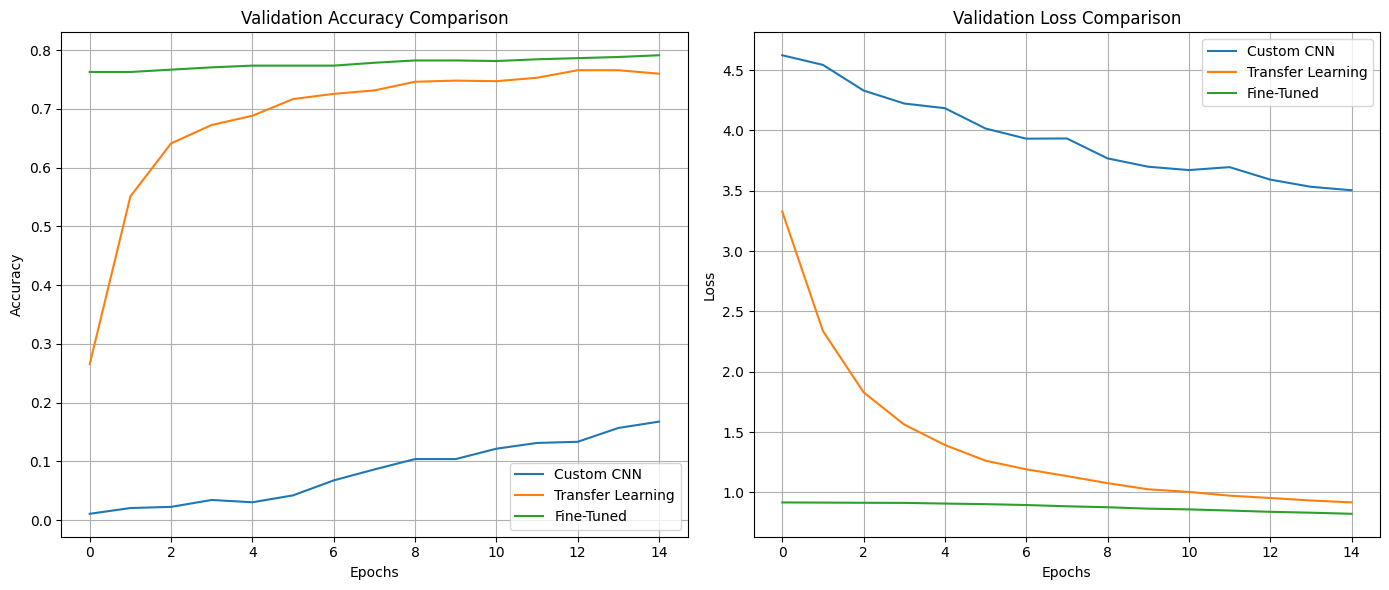

193/193 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step


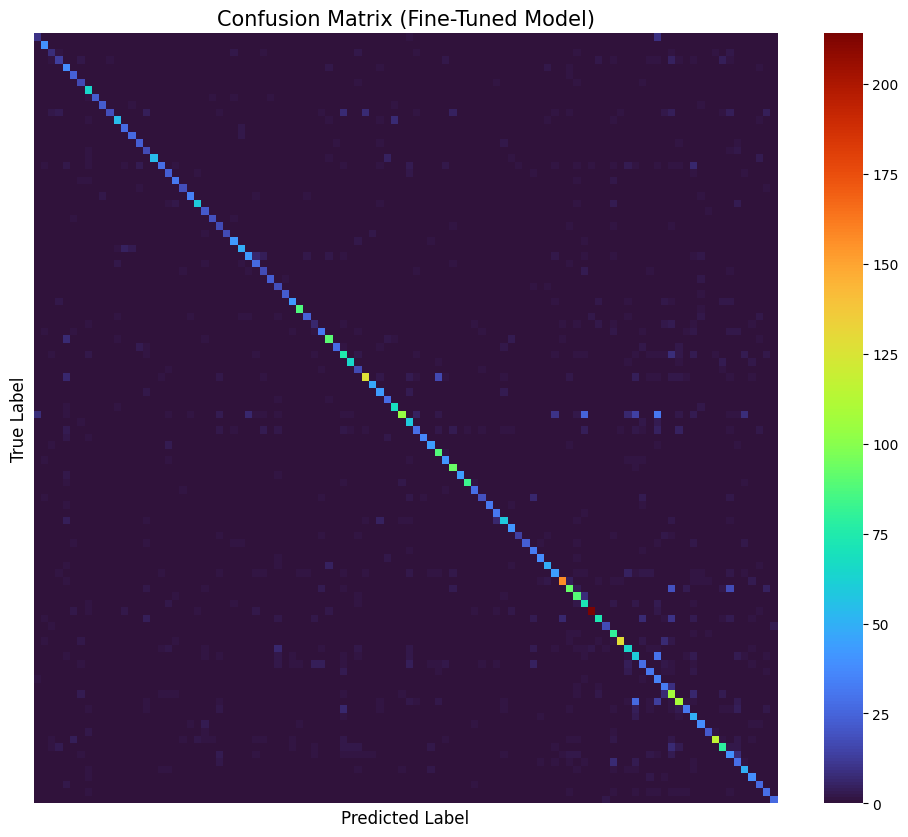

In [8]:
# Καμπύλες Σύγκλισης
def plot_comparison(histories, titles):
    plt.figure(figsize=(14, 6))


    plt.subplot(1, 2, 1)
    for i, hist in enumerate(histories):
        plt.plot(hist.history['val_accuracy'], label=titles[i])
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)


    plt.subplot(1, 2, 2)
    for i, hist in enumerate(histories):
        plt.plot(hist.history['val_loss'], label=titles[i])
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_comparison([history_1, history_2, history_3],
                ['Custom CNN', 'Transfer Learning', 'Fine-Tuned'])

# Δημιουργία Confusion Matrix (Fine-Tuned Model)

y_pred = model_3.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)

plt.figure(figsize=(12, 10))

cm = confusion_matrix(y_true, y_pred_classes)

sns.heatmap(cm, cmap='turbo', xticklabels=False, yticklabels=False)

plt.title('Confusion Matrix (Fine-Tuned Model)', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

plt.show()

In [9]:

def get_metrics(hist):
    train_acc = hist.history['accuracy'][-1]
    val_acc = hist.history['val_accuracy'][-1]
    return train_acc, val_acc

t1, v1 = get_metrics(history_1)
t2, v2 = get_metrics(history_2)
t3, v3 = get_metrics(history_3)

# Δημιουργία δεδομένων πίνακα
results_data = [
    ["Custom CNN", f"{t1:.2%}", f"{v1:.2%}", f"{acc_1:.2%}", f"{time_1:.1f}s"],
    ["Transfer Learning", f"{t2:.2%}", f"{v2:.2%}", f"{acc_2:.2%}", f"{time_2:.1f}s"],
    ["Fine-Tuning", f"{t3:.2%}", f"{v3:.2%}", f"{acc_3:.2%}", f"{time_3:.1f}s"]
]


columns = ["Μοντέλο", "Train Acc.", "Val Acc.", "Test Acc.", "Χρόνος"]

df_results = pd.DataFrame(results_data, columns=columns)

print("             ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ & ΣΥΓΚΛΙΣΗ")
print(df_results.to_string(index=False))

print("             Ερμηνεία Σύγκλισης ")
print("1. Αν Train Acc >> Val Acc: Το μοντέλο κάνει Overfitting.")
print("2. Αν Train & Val είναι χαμηλά: Το μοντέλο θέλει περισσότερη εκπαίδευση.")
print("3. Αν Train ≈ Val και υψηλά: Ιδανική Σύγκλιση.")

             ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ & ΣΥΓΚΛΙΣΗ
          Μοντέλο Train Acc. Val Acc. Test Acc. Χρόνος
       Custom CNN     11.86%   16.76%    13.50% 278.2s
Transfer Learning     98.24%   75.98%    74.50% 283.1s
      Fine-Tuning     93.92%   79.12%    77.23% 291.6s
             Ερμηνεία Σύγκλισης 
1. Αν Train Acc >> Val Acc: Το μοντέλο κάνει Overfitting.
2. Αν Train & Val είναι χαμηλά: Το μοντέλο θέλει περισσότερη εκπαίδευση.
3. Αν Train ≈ Val και υψηλά: Ιδανική Σύγκλιση.
